In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#reading the cleaned data set
df =pd.read_csv("data_cleaned.csv")

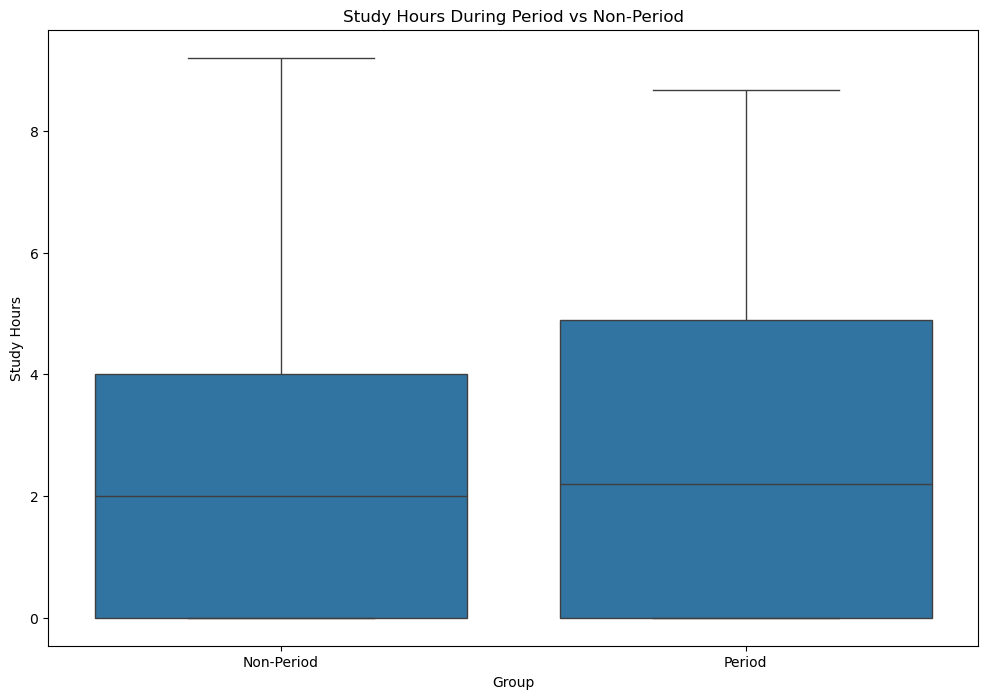

In [ ]:
#Displaying the Period vs Non-Period Study Hours via boxplot
plt.figure(figsize=(12,8))
sns.boxplot(x=df['is_period'], y=df['study_hours_daily'])
plt.xticks([0,1], ["Non-Period", "Period"])
plt.title("Study Hours During Period vs Non-Period")
plt.xlabel("Group")
plt.ylabel("Study Hours")
plt.show()

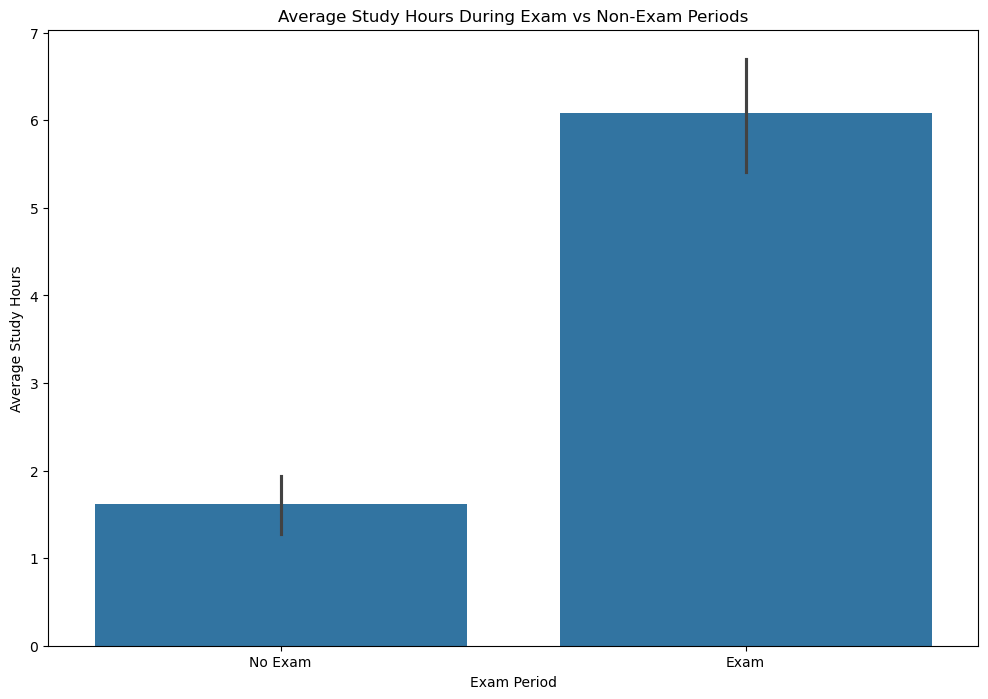

In [ ]:
#Displaying the Avarage study hours during exam periods vs non-xxam periods via barplot
plt.figure(figsize=(12,8))
sns.barplot(data=df, x='exam_period', y='study_hours_daily')
plt.xticks([0,1], ["No Exam", "Exam"])
plt.title("Average Study Hours During Exam vs Non-Exam Periods")
plt.xlabel("Exam Period")
plt.ylabel("Average Study Hours")
plt.show()


In [ ]:
# This code creates a correct 'cycle_day' variable by first identifying 
# consecutive menstrual period segments and then numbering the days within 
# each segment starting from 1. Each menstrual cycle is treated separately, 
# so cycle days restart at 1 for every new period. Non-period days are 
# assigned NaN because cycle_day is only meaningful during period days.

df['cycle_group'] = (df['is_period'] != df['is_period'].shift()).cumsum()
df['cycle_day'] = df.groupby('cycle_group').cumcount() + 1
df.loc[df['is_period'] == 0, 'cycle_day'] = np.nan


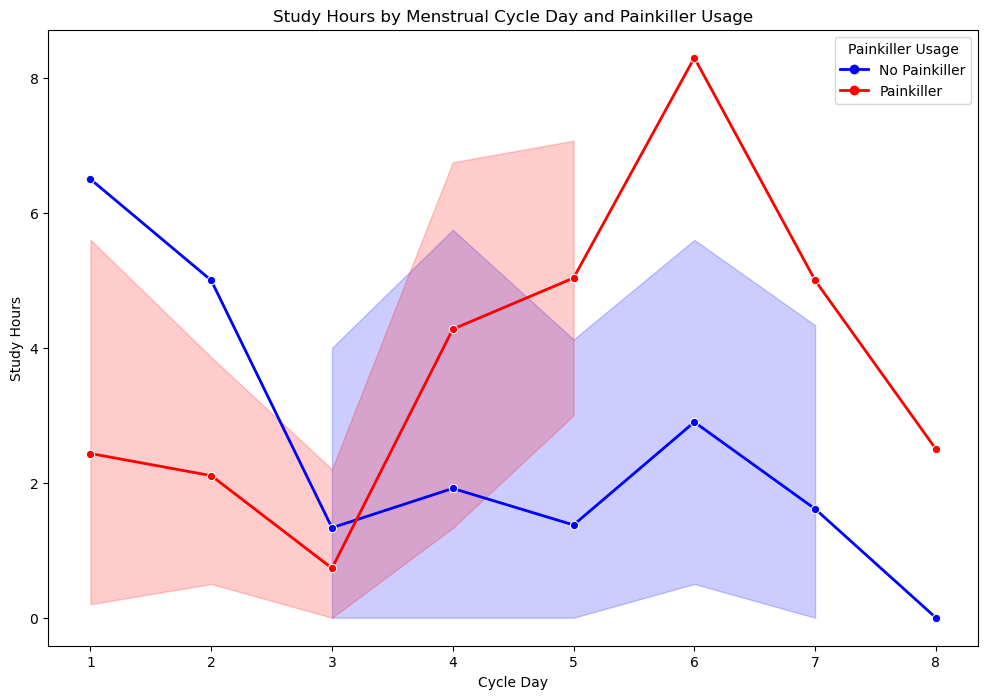

In [ ]:
#Displaying the study hours by mentrual cycle and painkiller usage via line plot
from matplotlib.lines import Line2D

period_df = df[df['is_period'] == 1]

plt.figure(figsize=(12,8))
sns.lineplot(
    data=period_df,
    x='cycle_day',               
    y='study_hours_daily',
    hue='painkiller_usage',
    marker='o',
    palette={0: "blue", 1: "red"},  
)
plt.title("Study Hours by Menstrual Cycle Day and Painkiller Usage")
plt.xlabel("Cycle Day")
plt.ylabel("Study Hours")
custom_lines = [
    Line2D([0], [0], color="blue", marker='o', linewidth=2), 
    Line2D([0], [0], color="red", marker='o', linewidth=2)    
]

plt.legend(
    handles=custom_lines,
    labels=["No Painkiller", "Painkiller"],
    title="Painkiller Usage"
)

plt.show()


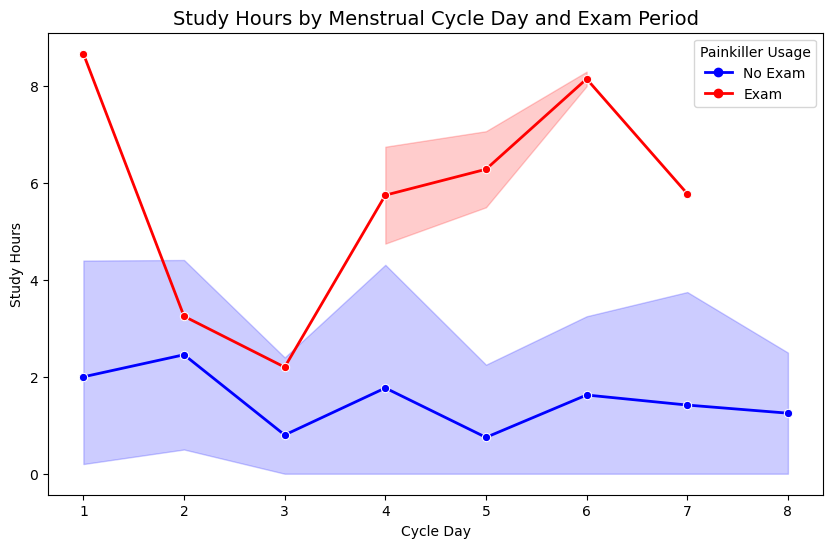

In [100]:

period_df = df[df['is_period'] == 1]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=period_df,
    x='cycle_day',
    y='study_hours_daily',
    hue='exam_period',
    marker="o",
    palette={0: "blue", 1: "red"},
    linewidth=2
)


plt.title("Study Hours by Menstrual Cycle Day and Exam Period", fontsize=14)
plt.xlabel("Cycle Day")
plt.ylabel("Study Hours")
legend_labels = ["No Exam", "Exam"] 
custom_lines = [
    Line2D([0], [0], color="blue", marker='o', linewidth=2),  
    Line2D([0], [0], color="red", marker='o', linewidth=2)   
]

plt.legend(
    handles=custom_lines,
    labels=["No Exam", "Exam"],
    title="Painkiller Usage"
)

plt.show()


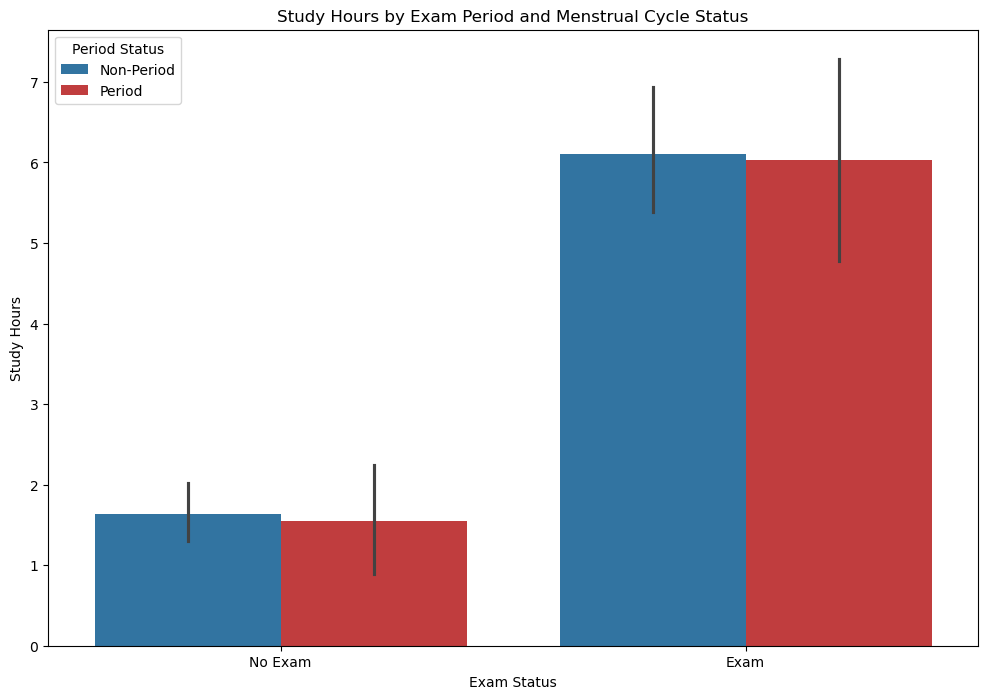

In [ ]:
#Displaying study hours by painkiller usage nad menstrual cycle status via barplot
plt.figure(figsize=(12,8))

# Barplot
ax = sns.barplot(
    data=df,
    x='exam_period',
    y='study_hours_daily',
    hue='is_period',
    palette={0: "#1f77b4", 1: "#d62728"} 
)

plt.xticks([0,1], ["No Exam", "Exam"])
plt.xlabel("Exam Status")
plt.ylabel("Study Hours")

handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set_linewidth(2)


plt.legend(
    handles=handles,
    labels=["Non-Period", "Period"],
    title="Period Status",
    loc="upper left"
)

plt.title("Study Hours by Exam Period and Menstrual Cycle Status")
plt.show()


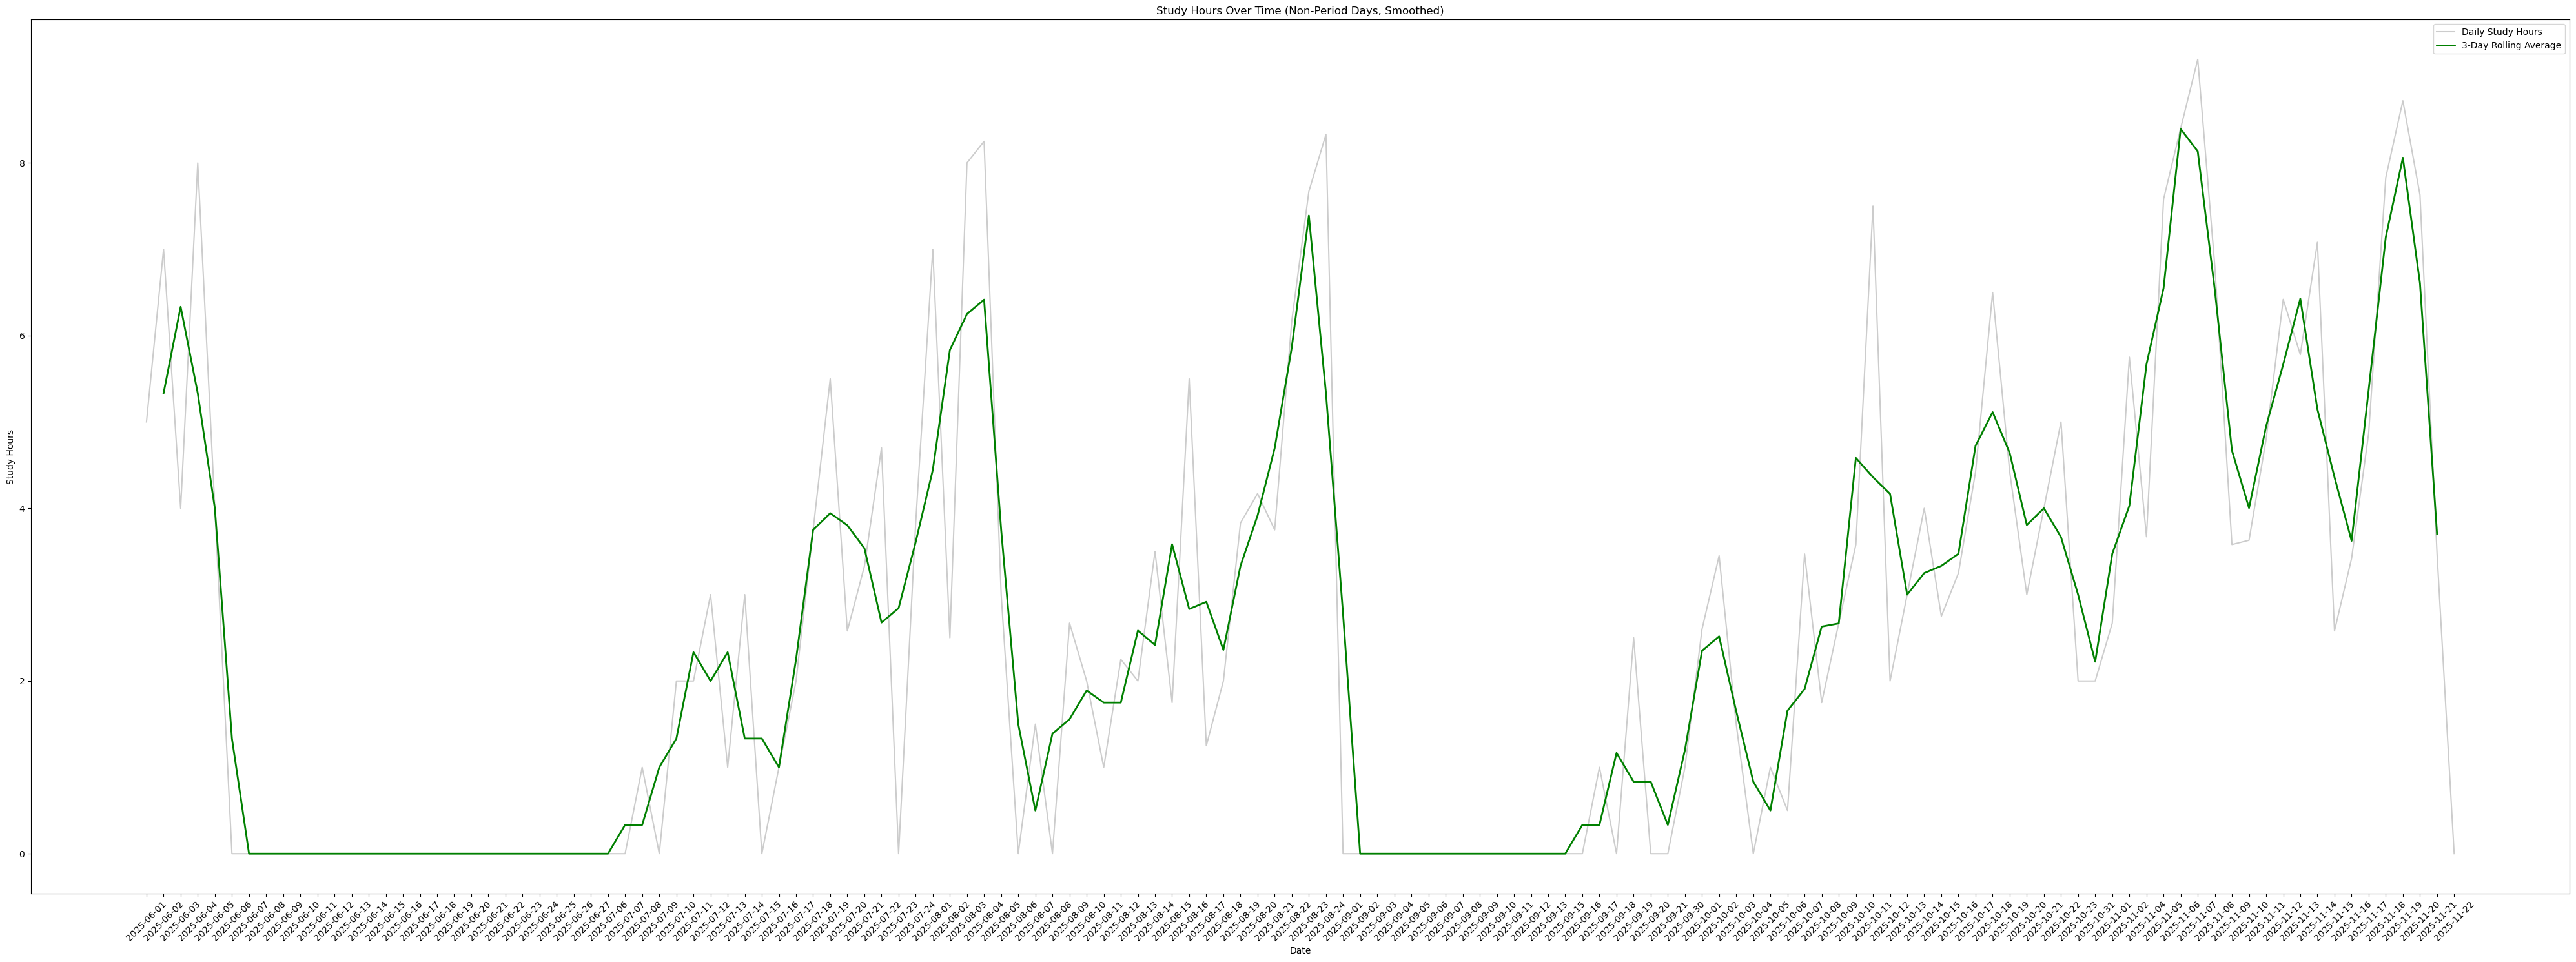

In [ ]:
#This code visualizes daily study hours for non-menstrual days alongside a smoothed 3-day rolling average to reveal clearer underlying trends by reducing daily fluctuations.

nonp_df = df[df['is_period']==0].copy()
nonp_df['rolling3'] = nonp_df['study_hours_daily'].rolling(window=3, center=True).mean()

plt.figure(figsize=(40,15))
plt.plot(nonp_df['date'], nonp_df['study_hours_daily'],
         alpha=0.4, color='gray', label='Daily Study Hours')

plt.plot(nonp_df['date'], nonp_df['rolling3'],
         linewidth=2, color='green', label='3-Day Rolling Average')

plt.title("Study Hours Over Time (Non-Period Days, Smoothed)")
plt.xlabel("Date")
plt.ylabel("Study Hours")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Select only numeric columns from the DataFrame and compute the correlation matrix among all numeric variables
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()

,painkiller_usage,study_hours_daily,exam_period,coffee_consumption,is_period
painkiller_usage,1.000000,0.219054,0.282775,-0.047809,0.197460
study_hours_daily,0.219054,1.000000,0.684765,0.184034,0.005293
exam_period,0.282775,0.684765,1.000000,0.044325,0.027869
coffee_consumption,-0.047809,0.184034,0.044325,1.000000,-0.023001
is_period,0.197460,0.005293,0.027869,-0.023001,1.000000


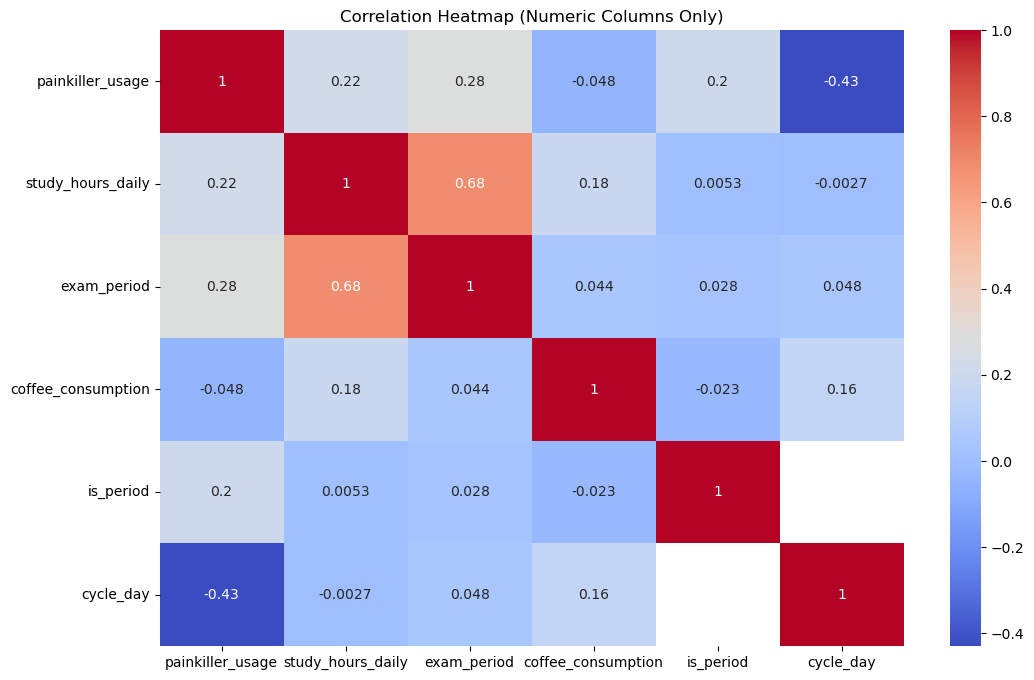

In [ ]:
#Visualize pairwise correlations of the numeric columns using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

